# Doo — Random Forest 모델

고객 이탈 예측을 위한 Random Forest 분류 모델입니다.

- Train 데이터로만 학습합니다.
- Validation 데이터로 성능과 임계값을 비교합니다.
- Test 데이터는 최종 모델 확정 전까지 사용하지 않습니다.
- 팀 공통 시드 `random_state=42`를 사용합니다.

In [1]:
from pathlib import Path
import pickle

import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "models":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "preprocessed"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")["churn"]
X_val = pd.read_csv(DATA_DIR / "X_val.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")["churn"]

with open(DATA_DIR / "preprocessor.pkl", "rb") as file:
    preprocessor = pickle.load(file)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## 1. 데이터 확인

피처, 자료형, 결측치와 타깃 분포를 확인합니다.

In [2]:
display(X_train.head())
display(pd.DataFrame({
    "dtype": X_train.dtypes,
    "train_missing": X_train.isna().sum(),
    "val_missing": X_val.isna().sum(),
}))
display(y_train.value_counts().rename_axis("churn").to_frame("count"))

,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.671757,1.614952,-0.407252,-0.671793,-0.406069,0.616805,0.0,1.0,1.0,0.0
1,-0.965400,-0.314654,-0.475206,-0.745705,-1.605762,-0.078723,0.0,1.0,0.0,0.0
2,-1.073778,0.274474,-0.475206,-0.736466,-1.245854,0.695333,0.0,1.0,0.0,0.0
3,-0.542093,-1.091619,-0.475206,-0.440820,-2.080423,-1.099580,0.0,1.0,0.0,1.0
4,-0.942516,0.641611,-0.407252,-0.487015,-0.473878,0.543887,1.0,1.0,0.0,0.0


,dtype,train_missing,val_missing
net_revenue,float64,0,0
recency_days,float64,0,0
frequency,float64,0,0
distinct_products,float64,0,0
tenure_days,float64,0,0
avg_days_between_orders,float64,0,0
is_low_value,float64,0,0
is_uk,float64,0,0
has_return,float64,0,0
recent_activity_ratio,float64,0,0


,count
churn,
0,1312
1,1280


## 2. 모델 학습

과적합을 줄이기 위해 트리 깊이와 리프의 최소 샘플 수를 제한합니다.

In [3]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(X_train, y_train)
print("학습 완료")

학습 완료


## 3. Validation 기본 성능

기본 분류 임계값 0.5에서 성능을 확인합니다.

In [4]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)

random_forest_val_pred = random_forest_model.predict(X_val)
random_forest_val_proba = random_forest_model.predict_proba(X_val)[:, 1]

random_forest_metrics_05 = pd.Series({
    "accuracy": accuracy_score(y_val, random_forest_val_pred),
    "recall": recall_score(y_val, random_forest_val_pred),
    "precision": precision_score(y_val, random_forest_val_pred),
    "f1": f1_score(y_val, random_forest_val_pred),
    "roc_auc": roc_auc_score(y_val, random_forest_val_proba),
}, name="threshold_0.50")

display(random_forest_metrics_05.to_frame())
print("Confusion matrix")
print(confusion_matrix(y_val, random_forest_val_pred))
print("\nClassification report")
print(classification_report(y_val, random_forest_val_pred, digits=3))

,threshold_0.50
accuracy,0.697917
recall,0.730679
precision,0.681223
f1,0.705085
roc_auc,0.764013


Confusion matrix
[[291 146]
 [115 312]]

Classification report
              precision    recall  f1-score   support

           0      0.717     0.666     0.690       437
           1      0.681     0.731     0.705       427

    accuracy                          0.698       864
   macro avg      0.699     0.698     0.698       864
weighted avg      0.699     0.698     0.698       864



## 4. 임계값 비교

Validation 데이터에서 Recall과 Precision의 균형을 비교합니다.

In [5]:
random_forest_threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]:
    random_forest_threshold_pred = (random_forest_val_proba >= threshold).astype(int)
    random_forest_threshold_results.append({
        "threshold": threshold,
        "recall": recall_score(y_val, random_forest_threshold_pred),
        "precision": precision_score(y_val, random_forest_threshold_pred, zero_division=0),
        "f1": f1_score(y_val, random_forest_threshold_pred, zero_division=0),
        "predicted_churn_count": int(random_forest_threshold_pred.sum()),
    })

random_forest_threshold_df = pd.DataFrame(random_forest_threshold_results)
display(random_forest_threshold_df.style.format({
    "threshold": "{:.2f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}",
}))

,threshold,recall,precision,f1,predicted_churn_count
0,0.30,0.913,0.614,0.734,635
1,0.35,0.871,0.627,0.729,593
2,0.40,0.843,0.643,0.729,560
3,0.45,0.787,0.658,0.716,511
4,0.50,0.731,0.681,0.705,458
5,0.55,0.674,0.692,0.683,416
6,0.60,0.588,0.707,0.642,355
7,0.65,0.489,0.736,0.588,284
8,0.70,0.363,0.764,0.492,203


## 5. 피처 중요도

Random Forest가 예측 분할에 많이 사용한 피처를 확인합니다. 중요도는 인과관계를 의미하지 않습니다.

In [6]:
random_forest_importance_df = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": random_forest_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(random_forest_importance_df)

,feature,importance
0,avg_days_between_orders,0.247329
1,net_revenue,0.186393
2,recency_days,0.175420
3,frequency,0.113989
4,distinct_products,0.108792
5,tenure_days,0.082114
6,recent_activity_ratio,0.061764
7,has_return,0.014034
8,is_low_value,0.007538
9,is_uk,0.002627


## 6. 혼동행렬 시각화

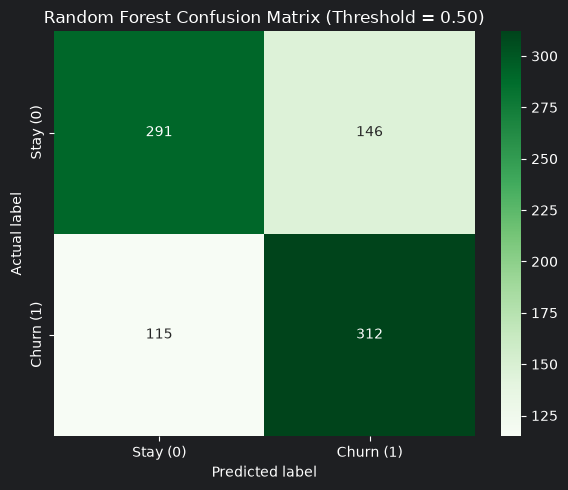

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

random_forest_confusion_matrix = confusion_matrix(y_val, random_forest_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_confusion_matrix, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Stay (0)", "Churn (1)"],
    yticklabels=["Stay (0)", "Churn (1)"],
)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Random Forest Confusion Matrix (Threshold = 0.50)")
plt.tight_layout()
plt.show()

## 7. 임계값별 성능 변화

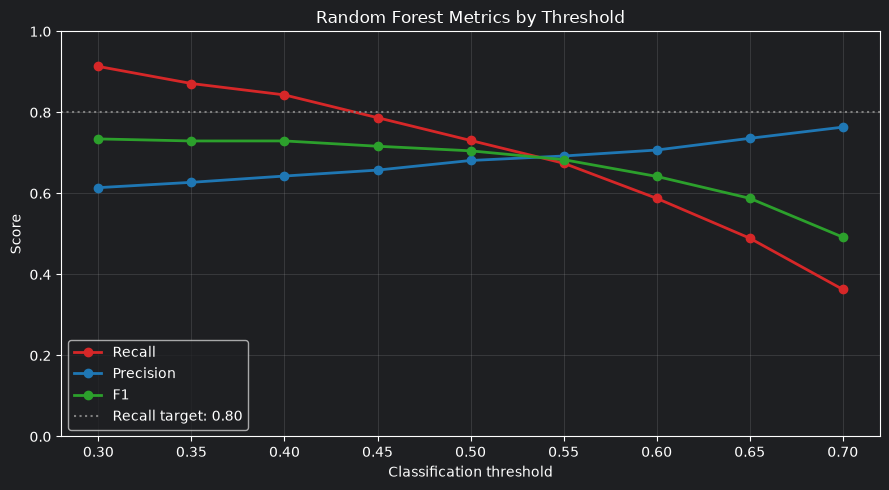

In [8]:
plt.figure(figsize=(9, 5))
for metric, color in [("recall", "tab:red"), ("precision", "tab:blue"), ("f1", "tab:green")]:
    plt.plot(
        random_forest_threshold_df["threshold"],
        random_forest_threshold_df[metric],
        marker="o", linewidth=2, color=color,
        label=metric.upper() if metric == "f1" else metric.title(),
    )
plt.axhline(0.80, color="gray", linestyle=":", label="Recall target: 0.80")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Random Forest Metrics by Threshold")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 8. ROC Curve와 Precision–Recall Curve

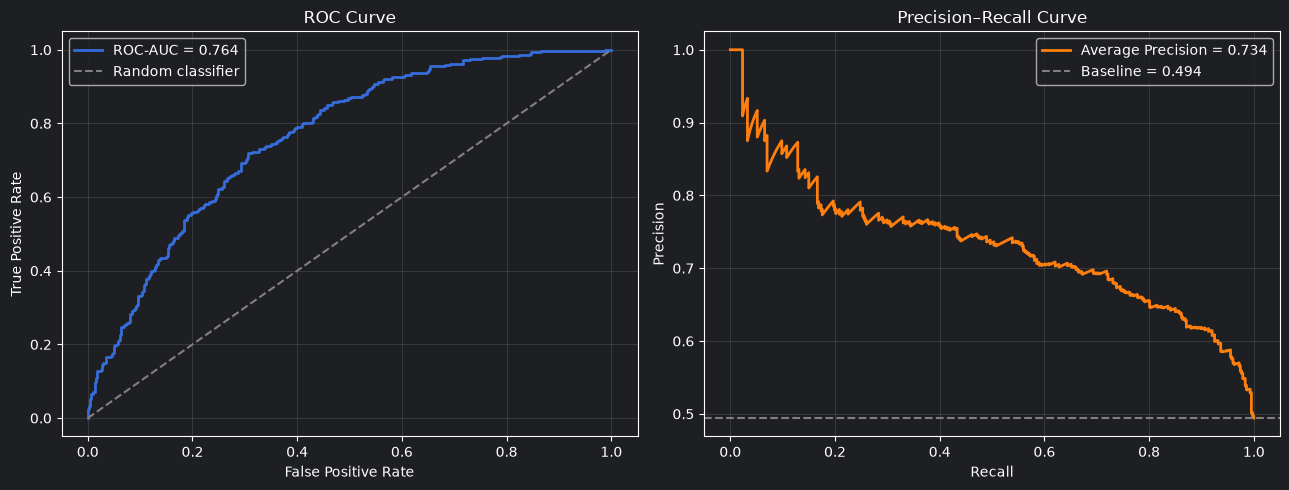

In [9]:
from sklearn.metrics import auc, average_precision_score, precision_recall_curve, roc_curve

random_forest_fpr, random_forest_tpr, _ = roc_curve(y_val, random_forest_val_proba)
random_forest_roc_auc = auc(random_forest_fpr, random_forest_tpr)
random_forest_pr_precision, random_forest_pr_recall, _ = precision_recall_curve(
    y_val, random_forest_val_proba
)
random_forest_average_precision = average_precision_score(y_val, random_forest_val_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(random_forest_fpr, random_forest_tpr, linewidth=2, label=f"ROC-AUC = {random_forest_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(
    random_forest_pr_recall, random_forest_pr_precision, linewidth=2,
    color="tab:orange", label=f"Average Precision = {random_forest_average_precision:.3f}",
)
axes[1].axhline(y_val.mean(), linestyle="--", color="gray", label=f"Baseline = {y_val.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 9. 피처 중요도 시각화

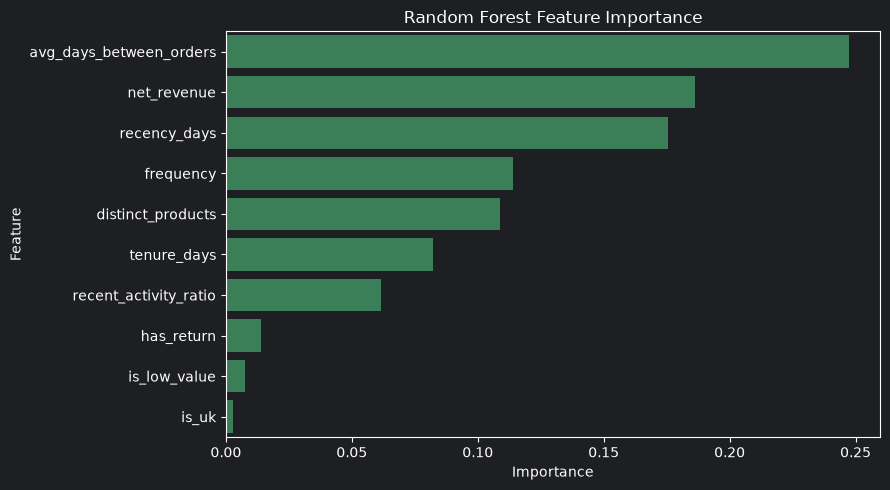

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=random_forest_importance_df,
    x="importance", y="feature", color="seagreen",
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. 실험 결과 기록

Recall 0.80 이상 후보 중 F1-score가 가장 높은 임계값을 확인합니다.

In [11]:
random_forest_candidates = random_forest_threshold_df[
    random_forest_threshold_df["recall"] >= 0.80
]
if random_forest_candidates.empty:
    print("Recall 0.80 이상인 임계값 후보가 없습니다.")
else:
    random_forest_best_candidate = random_forest_candidates.loc[
        random_forest_candidates["f1"].idxmax()
    ]
    display(random_forest_best_candidate.to_frame("selected_value"))

,selected_value
threshold,0.300000
recall,0.913349
precision,0.614173
f1,0.734463
predicted_churn_count,635.000000


## 11. 모델 구성 및 평가 기준 설명

이 노트북은 수업에서 배운 `RandomForestClassifier`의 기본 흐름인 **모델 생성 → 학습 → 예측 → 평가 → 피처 중요도 확인**을 고객 이탈 예측 문제에 맞게 확장했다.

### 데이터 사용 원칙

- 팀장이 동일한 기준으로 생성한 `X_train`, `y_train`, `X_val`, `y_val`을 사용해 팀원 간 모델 비교 조건을 통일했다.
- Random Forest는 스케일링이 필수는 아니지만 모든 모델이 동일한 전처리 데이터를 사용하도록 팀 공통 파일을 그대로 사용했다.
- Test 데이터는 최종 모델을 결정한 뒤 한 번만 평가하기 위해 이 노트북에서 불러오지 않았다.

### Random Forest를 사용한 이유

- 여러 결정트리의 결과를 결합해 단일 결정트리보다 안정적인 예측을 할 수 있다.
- Logistic Regression이 표현하기 어려운 비선형 관계와 피처 간 상호작용을 학습할 수 있다.
- `feature_importances_`로 예측에 많이 사용된 피처를 확인할 수 있다.

### 주요 하이퍼파라미터 설정 이유

- `n_estimators=500`: 여러 트리의 결과를 평균내 예측 변동을 줄인다.
- `max_depth=8`: 트리가 지나치게 깊어져 Train 데이터에 과적합되는 것을 제한한다.
- `min_samples_leaf=5`: 소수 고객만 포함하는 지나치게 세부적인 분기를 방지한다.
- `max_features='sqrt'`: 각 분기에서 일부 피처만 고려해 트리 사이의 다양성을 높인다.
- `class_weight='balanced'`: 클래스별 표본 비율을 반영한다. 현재 데이터는 거의 균형이므로 추후 `None` 설정과 비교할 수 있다.
- `random_state=42`는 팀 공통 재현성 기준이고, `n_jobs=-1`은 가능한 CPU 코어를 병렬로 사용한다.

### Recall과 임계값을 함께 확인한 이유

실제 이탈 고객을 놓치는 경우를 줄이기 위해 Recall을 우선한다. 기본 임계값 0.5뿐 아니라 0.30~0.70을 비교하여 Recall, Precision, F1-score와 예측 대상 고객 수의 변화를 확인했다. Recall만 높이면 지나치게 많은 고객을 이탈로 분류할 수 있으므로 Precision과 F1-score도 함께 비교한다.

### 평가 및 시각화 목적

- 혼동행렬: 실제 이탈 고객을 놓친 수와 잔류 고객을 잘못 선별한 수를 확인한다.
- ROC-AUC와 Precision–Recall Curve: 모델의 전반적인 순위화 능력과 Recall–Precision 균형을 확인한다.
- 피처 중요도: 예측 분할에 많이 사용된 피처를 확인한다. 중요도가 높다는 것은 인과관계나 이탈 방향을 의미하지 않는다.

현재 설정은 첫 비교를 위한 베이스라인이다. 최종 후보를 만들 때는 Train 데이터 내부 교차검증으로 과적합 여부를 확인하고 필요하면 `oob_score`, `GridSearchCV` 등을 추가한다. 최종 선정은 동일한 Validation 데이터와 평가 규칙으로 Logistic Regression 및 다른 모델과 비교해 결정한다.